# Seasonal Agriculture Performance Analysis

### From seasonal patterns to practical farm decisions

**Project type:** Data Analytics Internship — Major Project  
**Dataset:** Seasonal agriculture performance records

---

## Why I chose this angle

Instead of treating this as a generic agricultural dataset analysis, I focused on one practical question:

> **Which seasonal combinations of crop, irrigation and farm conditions appear to give a better balance of profitability, productivity and water efficiency?**

This keeps the analysis close to the data while making the final findings useful for seasonal planning.

### Analytical questions
1. How does farm performance change across Kharif, Rabi and Zaid?
2. Which crops perform better in different seasons?
3. Does irrigation method show a noticeable trade-off between profit and water efficiency?
4. Which crop–season combinations deserve closer attention?
5. Are the relationships in the data strong enough to support recommendations, or only to suggest areas for further investigation?

> **Important:** This is observational analysis. The patterns below show associations in the dataset, not proof that one factor directly causes another.


In [1]:
# Basic setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# If you are using Google Colab, run this once if the CSV is not already in the runtime:
# from google.colab import files
# uploaded = files.upload()

DATA_PATH = "seasonal_agriculture_performance_dataset.csv"
df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded successfully: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()


Dataset loaded successfully: 4,000 rows × 28 columns


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


## 1. Dataset structure and first look

In [2]:
# Top 5 rows
df.head(5)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [3]:
# Shape, columns and data types
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)

print("\nUnique values in key categorical columns:")
for col in ["State", "District", "Crop", "Season", "Irrigation_Method"]:
    print(f"{col}: {df[col].nunique()} unique values")


Shape: (4000, 28)

Data types:
Farm_ID                              str
State                                str
District                             str
Crop                                 str
Season                               str
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                          float64
Soil_Moisture_pct                float64
Nitrogen_kg_ha                   float64
Phosphorus_kg_ha                 float64
Potassium_kg_ha                  float64
Irrigation_Method                    str
Fertilizer_kg_ha                 float64
Pesticide_Litre_ha               float64
Seed_Quality_Score               float64
Yield_Tonnes_Ha                  float64
Production_Tonnes                float64
Market_Price_INR_Tonne             int64
Total_Cost_INR                     int64
Revenue_INR               

In [4]:
# Quick statistical summary
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,"4,000.00",7.89,4.22,0.50,4.26,7.89,11.65,15.00
Rainfall_mm,"3,952.00",601.15,288.93,80.00,370.20,582.00,834.95,"1,395.20"
Avg_Temperature_C,"4,000.00",26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,"4,000.00",63.21,11.96,25.00,54.77,63.00,71.90,95.00
Sunlight_Hours_Day,"4,000.00",7.32,1.12,3.50,6.60,7.30,8.10,11.00
Soil_pH,"4,000.00",6.70,0.64,5.20,6.26,6.69,7.14,8.40
Soil_Moisture_pct,"3,960.00",26.51,6.71,8.00,21.70,26.40,31.30,47.00
Nitrogen_kg_ha,"4,000.00",120.25,31.22,40.00,98.50,120.10,141.22,220.00
Phosphorus_kg_ha,"4,000.00",57.78,17.02,15.00,46.20,57.50,69.40,120.00
Potassium_kg_ha,"4,000.00",104.76,27.74,30.00,86.20,105.10,123.60,200.00


### Initial observation

The dataset has 4,000 farm records and a mix of categorical, environmental, resource-use and financial variables. The presence of both **Yield_Tonnes_Ha**, **Profit_INR** and **Water_Efficiency_t_per_1000m3** makes it possible to look beyond yield alone and study the economic and resource side of performance.


## 2. Data quality: missing values and duplicates

In [5]:
# Missing values
missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0]


Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

In [6]:
# Duplicate records
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

# Farm IDs should normally be unique
print("Unique Farm_IDs:", df["Farm_ID"].nunique())


Duplicate rows: 0
Unique Farm_IDs: 4000


### Handling decision

There are missing values in **Rainfall_mm, Soil_Moisture_pct and Yield_Tonnes_Ha**. I did not blindly fill the target variable (yield), because doing that could create artificial performance values.

- Rainfall and soil moisture can be filled using **season-level medians**.
- For yield-based analysis, records with missing yield are excluded only from that particular calculation.
- Profitability analysis can still use the original profit values.
- No duplicate rows were found, so no duplicate records need to be removed.


In [7]:
# Make a working copy and fill environmental gaps by season
data = df.copy()

for col in ["Rainfall_mm", "Soil_Moisture_pct"]:
    data[col] = data.groupby("Season")[col].transform(lambda s: s.fillna(s.median()))

print("Remaining missing values:")
print(data.isna().sum()[data.isna().sum() > 0])


Remaining missing values:
Yield_Tonnes_Ha    32
dtype: int64


## 3. Outlier investigation

In [8]:
# IQR-based outlier counts for important performance variables
def iqr_report(series):
    x = series.dropna()
    q1, q3 = x.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((x < lower) | (x > upper)).sum()
    return q1, q3, lower, upper, int(count)

for col in ["Yield_Tonnes_Ha", "Profit_INR", "Water_Efficiency_t_per_1000m3", "Revenue_INR"]:
    q1, q3, lower, upper, count = iqr_report(data[col])
    print(f"{col}: {count} IQR outliers | lower={lower:,.2f}, upper={upper:,.2f}")


Yield_Tonnes_Ha: 302 IQR outliers | lower=-1.63, upper=5.52
Profit_INR: 404 IQR outliers | lower=-696,111.00, upper=763,567.00
Water_Efficiency_t_per_1000m3: 322 IQR outliers | lower=-3.57, upper=10.38
Revenue_INR: 240 IQR outliers | lower=-736,519.00, upper=1,780,911.00


### Outlier decision

The yield and profit distributions are strongly right-skewed. I therefore **investigated outliers instead of deleting them automatically**. Very large values may come from particular crops or larger production systems, and removing them could hide a genuine pattern.

For comparisons, I will show **medians alongside means** where useful. This is more robust for this dataset.


## 4. Descriptive analysis

In [9]:
# Key descriptive statistics
key_cols = [
    "Farm_Area_Hectares", "Rainfall_mm", "Avg_Temperature_C",
    "Soil_Moisture_pct", "Fertilizer_kg_ha", "Yield_Tonnes_Ha",
    "Market_Price_INR_Tonne", "Total_Cost_INR", "Revenue_INR",
    "Profit_INR", "Water_Used_m3", "Water_Efficiency_t_per_1000m3",
    "Disease_Pest_Risk_pct"
]
data[key_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,"4,000.00",7.89,4.22,0.50,4.26,7.89,11.65,15.00
Rainfall_mm,"4,000.00",600.71,288.43,80.00,370.43,581.00,836.12,"1,395.20"
Avg_Temperature_C,"4,000.00",26.82,3.82,16.20,23.90,26.90,29.60,39.70
Soil_Moisture_pct,"4,000.00",26.50,6.70,8.00,21.70,26.40,31.20,47.00
Fertilizer_kg_ha,"4,000.00",186.04,60.26,40.00,143.97,186.25,227.20,400.00
Yield_Tonnes_Ha,"3,968.00",5.27,13.36,0.30,1.05,1.74,2.84,101.44
Market_Price_INR_Tonne,"4,000.00","44,714.17","30,266.16","2,594.00","21,429.25","25,913.00","68,279.00","131,240.00"
Total_Cost_INR,"4,000.00","526,303.58","294,419.14","26,826.00","274,577.50","519,082.50","761,996.50","1,349,990.00"
Revenue_INR,"4,000.00","637,860.05","636,974.71","6,107.00","207,517.25","456,830.50","836,874.75","5,080,900.00"
Profit_INR,"4,000.00","111,556.46","545,081.89","-1,019,223.00","-148,731.75","3,673.00","216,187.75","4,345,421.00"


## 5. Univariate analysis

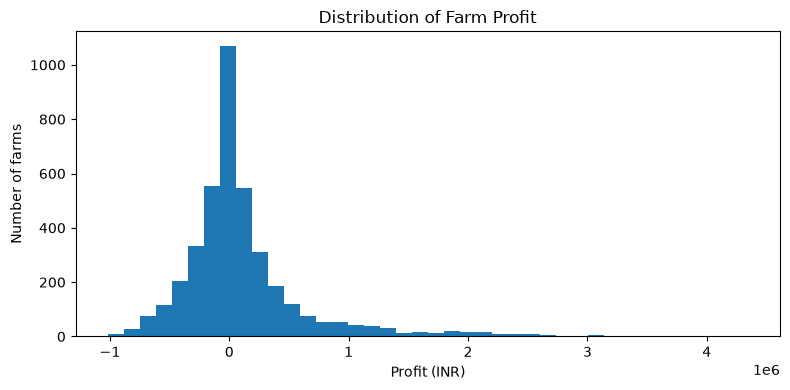

In [10]:
# Distribution of the main performance measures
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(data["Profit_INR"].dropna(), bins=40)
ax.set_title("Distribution of Farm Profit")
ax.set_xlabel("Profit (INR)")
ax.set_ylabel("Number of farms")
plt.tight_layout()
plt.show()


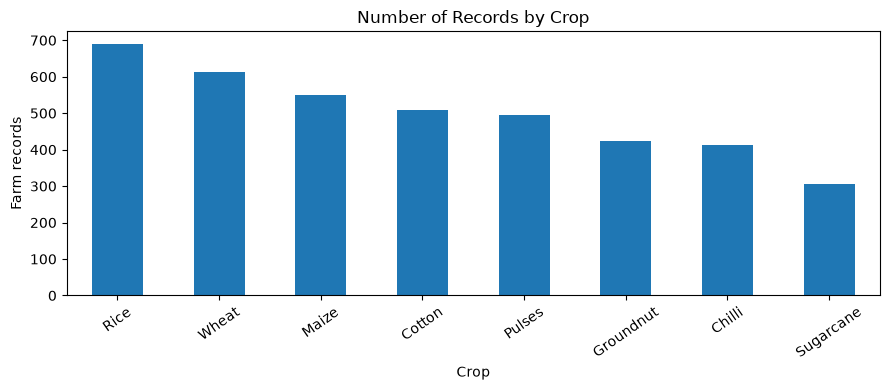

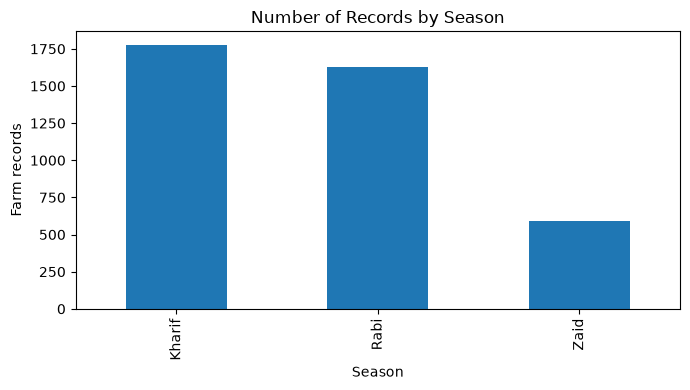

In [11]:
# Crop and season counts
fig, ax = plt.subplots(figsize=(9, 4))
data["Crop"].value_counts().plot(kind="bar", ax=ax)
ax.set_title("Number of Records by Crop")
ax.set_xlabel("Crop")
ax.set_ylabel("Farm records")
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
data["Season"].value_counts().plot(kind="bar", ax=ax)
ax.set_title("Number of Records by Season")
ax.set_xlabel("Season")
ax.set_ylabel("Farm records")
plt.tight_layout()
plt.show()


## 6. Seasonal comparison

In [12]:
data["Profitable"] = data["Profit_INR"] > 0

season_summary = data.groupby("Season").agg(
    Farms=("Farm_ID", "count"),
    Mean_Yield=("Yield_Tonnes_Ha", "mean"),
    Median_Yield=("Yield_Tonnes_Ha", "median"),
    Mean_Profit=("Profit_INR", "mean"),
    Median_Profit=("Profit_INR", "median"),
    Mean_Water=("Water_Used_m3", "mean"),
    Mean_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Mean_Disease_Risk=("Disease_Pest_Risk_pct", "mean"),
    Profitable_Farm_Rate=("Profitable", "mean")
).reset_index()

season_summary["Profitable_Farm_Rate"] *= 100
season_summary.round(2)


,Season,Farms,Mean_Yield,Median_Yield,Mean_Profit,Median_Profit,Mean_Water,Mean_Water_Efficiency,Mean_Disease_Risk,Profitable_Farm_Rate
0,Kharif,1779,5.64,1.95,"178,914.65","38,808.00","6,102.20",5.89,54.47,57.79
1,Rabi,1627,5.08,1.66,"87,689.47","-3,187.00","5,846.99",5.19,40.48,48.86
2,Zaid,594,4.67,1.45,"-24,804.82","-62,144.00","6,419.89",4.41,38.22,35.52


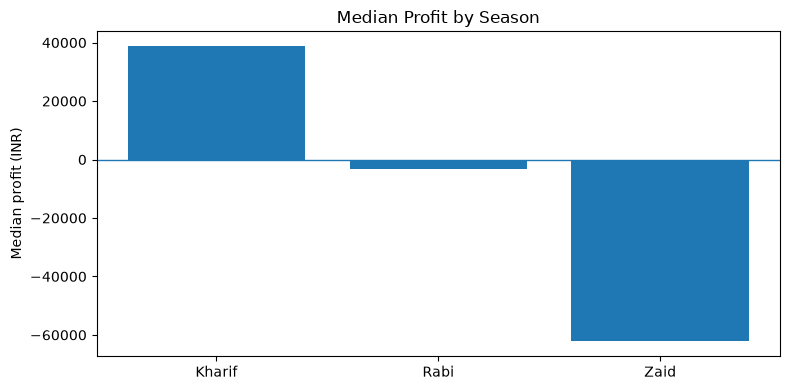

In [13]:
# Seasonal profit comparison
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(season_summary["Season"], season_summary["Median_Profit"])
ax.axhline(0, linewidth=1)
ax.set_title("Median Profit by Season")
ax.set_ylabel("Median profit (INR)")
plt.tight_layout()
plt.show()


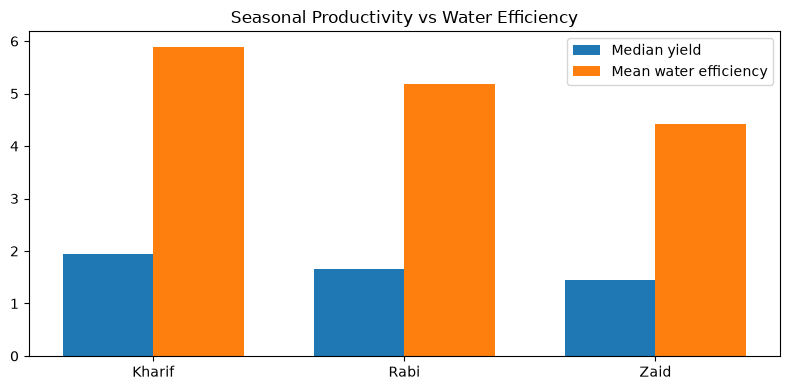

In [14]:
# Seasonal yield and water efficiency
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(season_summary))
width = 0.36
ax.bar(x - width/2, season_summary["Median_Yield"], width, label="Median yield")
ax.bar(x + width/2, season_summary["Mean_Water_Efficiency"], width, label="Mean water efficiency")
ax.set_xticks(x)
ax.set_xticklabels(season_summary["Season"])
ax.set_title("Seasonal Productivity vs Water Efficiency")
ax.legend()
plt.tight_layout()
plt.show()


### Seasonal reading

The seasonal comparison suggests that **Kharif is the strongest overall period in this dataset**, while Zaid shows the weakest profitability. I would not interpret this as a universal agricultural rule; it is a pattern within the supplied records.

The gap between mean and median yield/profit also shows why relying on averages alone would be misleading.


## 7. Bivariate analysis: crop × season

In [15]:
crop_season = data.groupby(["Crop", "Season"]).agg(
    Farms=("Farm_ID", "count"),
    Median_Yield=("Yield_Tonnes_Ha", "median"),
    Median_Profit=("Profit_INR", "median"),
    Mean_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Profitable_Rate=("Profitable", "mean")
).reset_index()

crop_season["Profitable_Rate"] *= 100
crop_season.sort_values("Median_Profit", ascending=False).head(15).round(2)


,Crop,Season,Farms,Median_Yield,Median_Profit,Mean_Water_Efficiency,Profitable_Rate
18,Sugarcane,Kharif,125,56.65,"940,895.00",36.00,92.00
0,Chilli,Kharif,185,1.78,"705,116.00",3.26,85.41
19,Sugarcane,Rabi,129,45.46,"622,229.00",27.92,85.27
20,Sugarcane,Zaid,51,38.78,"556,627.00",23.39,88.24
1,Chilli,Rabi,163,1.56,"470,004.00",2.89,78.53
2,Chilli,Zaid,64,1.22,"350,401.00",2.20,81.25
3,Cotton,Kharif,215,1.44,"136,193.00",2.13,72.09
6,Groundnut,Kharif,193,1.52,"87,406.00",3.58,66.84
12,Pulses,Kharif,221,1.09,"57,156.00",3.35,62.90
4,Cotton,Rabi,201,1.20,"50,603.00",1.94,66.17


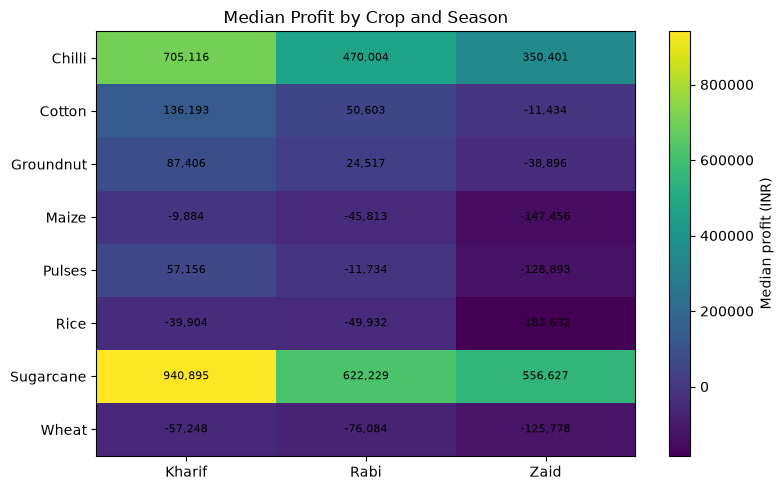

In [16]:
# Heatmap-like pivot using matplotlib only
pivot = crop_season.pivot(index="Crop", columns="Season", values="Median_Profit")

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(pivot.values, aspect="auto")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_title("Median Profit by Crop and Season")
fig.colorbar(im, ax=ax, label="Median profit (INR)")

for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        value = pivot.iloc[i, j]
        ax.text(j, i, f"{value:,.0f}", ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()


### What stands out

The strongest financial results are concentrated in **Sugarcane and Chilli**, especially in Kharif and Rabi. In contrast, several cereal crop combinations show negative median profit.

This is one reason a single “best season” answer is incomplete: **crop choice changes the story.**


## 8. Student-designed analysis 1 — Irrigation trade-off

In [17]:
irrigation_summary = data.groupby("Irrigation_Method").agg(
    Farms=("Farm_ID", "count"),
    Median_Yield=("Yield_Tonnes_Ha", "median"),
    Median_Profit=("Profit_INR", "median"),
    Mean_Water_Used=("Water_Used_m3", "mean"),
    Mean_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Profitable_Rate=("Profitable", "mean")
).reset_index()

irrigation_summary["Profitable_Rate"] *= 100
irrigation_summary.round(2)


,Irrigation_Method,Farms,Median_Yield,Median_Profit,Mean_Water_Used,Mean_Water_Efficiency,Profitable_Rate
0,Drip,915,1.96,"52,895.00","5,918.75",6.27,59.78
1,Flood,1310,1.63,"-12,131.00","8,026.47",3.44,47.18
2,Rainfed,1041,1.72,"-9,650.00","3,549.55",7.56,46.88
3,Sprinkler,734,1.80,"7,840.00","6,208.26",4.67,51.91


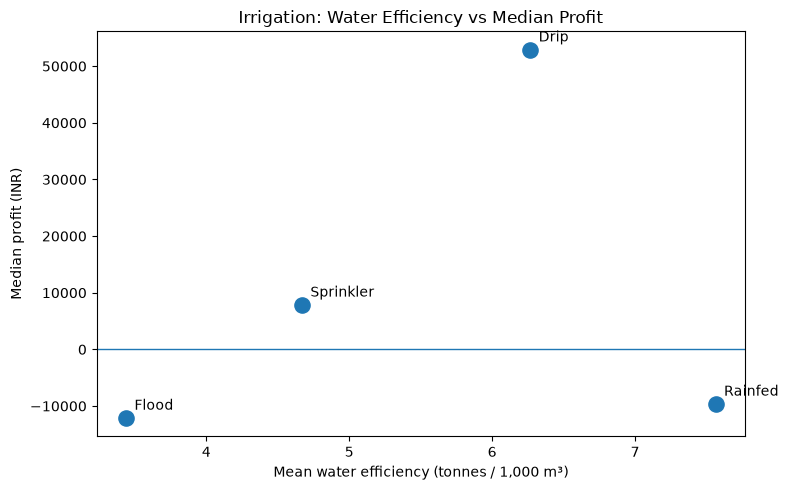

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(
    irrigation_summary["Mean_Water_Efficiency"],
    irrigation_summary["Median_Profit"],
    s=120
)

for _, row in irrigation_summary.iterrows():
    ax.annotate(
        row["Irrigation_Method"],
        (row["Mean_Water_Efficiency"], row["Median_Profit"]),
        xytext=(6, 6),
        textcoords="offset points"
    )

ax.axhline(0, linewidth=1)
ax.set_title("Irrigation: Water Efficiency vs Median Profit")
ax.set_xlabel("Mean water efficiency (tonnes / 1,000 m³)")
ax.set_ylabel("Median profit (INR)")
plt.tight_layout()
plt.show()


**Interpretation:** Drip stands out as a particularly interesting combination of relatively high water efficiency and positive median profit. Rainfed has high water efficiency too, but its profitability is more dependent on the crop and season.

I would treat this as a **decision signal for deeper investigation**, not proof that irrigation method alone caused the financial difference.


## 9. Student-designed analysis 2 — Profitability risk by season

In [19]:
risk_table = data.groupby(["Crop", "Season"]).agg(
    Farms=("Farm_ID", "count"),
    Loss_Rate=("Profitable", lambda s: (1 - s.mean()) * 100),
    Median_Profit=("Profit_INR", "median"),
    Median_Yield=("Yield_Tonnes_Ha", "median")
).reset_index()

# Show combinations with at least 50 records for a fairer comparison
risk_table[risk_table["Farms"] >= 50].sort_values(
    ["Loss_Rate", "Median_Profit"], ascending=[False, True]
).head(15).round(2)


,Crop,Season,Farms,Loss_Rate,Median_Profit,Median_Yield
23,Wheat,Zaid,85,91.76,"-125,778.00",1.84
17,Rice,Zaid,102,87.25,"-183,631.50",1.94
11,Maize,Zaid,84,84.52,"-147,455.50",2.27
14,Pulses,Zaid,62,75.81,"-128,893.00",0.66
22,Wheat,Rabi,237,75.11,"-76,084.00",2.22
21,Wheat,Kharif,292,68.15,"-57,248.50",2.36
16,Rice,Rabi,274,67.52,"-49,931.50",2.38
10,Maize,Rabi,233,66.52,"-45,813.00",2.82
8,Groundnut,Zaid,54,59.26,"-38,896.50",1.10
15,Rice,Kharif,314,58.60,"-39,903.50",2.88


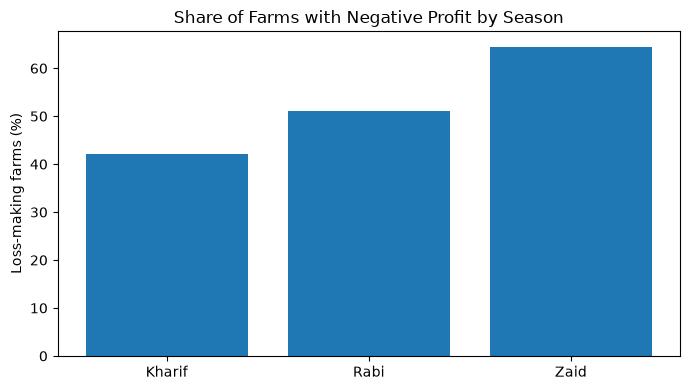

In [20]:
# Loss rate by season
season_loss = data.groupby("Season")["Profitable"].apply(lambda s: (1 - s.mean()) * 100)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(season_loss.index, season_loss.values)
ax.set_title("Share of Farms with Negative Profit by Season")
ax.set_ylabel("Loss-making farms (%)")
plt.tight_layout()
plt.show()


### Interpretation

Zaid has the highest loss-making share in the dataset. Some crop–season pairs are especially vulnerable; for example, Wheat and Rice in Zaid show very high loss rates.

This gives a more useful planning question than simply asking “which season has the highest yield?” — **where is the financial downside concentrated?**


## 10. Student-designed analysis 3 — Crop–season–irrigation opportunity matrix

In [21]:
combo = data.groupby(["Crop", "Season", "Irrigation_Method"]).agg(
    Farms=("Farm_ID", "count"),
    Median_Profit=("Profit_INR", "median"),
    Median_Yield=("Yield_Tonnes_Ha", "median"),
    Mean_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Profit_Rate=("Profitable", "mean")
).reset_index()

combo["Profit_Rate"] *= 100

# Avoid making decisions from tiny groups
opportunity = combo[combo["Farms"] >= 30].copy()

# Rank within the observed dataset, not as a universal farming score
opportunity["Profit_Rank"] = opportunity["Median_Profit"].rank(pct=True)
opportunity["Water_Rank"] = opportunity["Mean_Water_Efficiency"].rank(pct=True)

# A transparent exploratory score: equal weight to profitability and water efficiency
opportunity["Opportunity_Score"] = (
    0.5 * opportunity["Profit_Rank"] +
    0.5 * opportunity["Water_Rank"]
)

opportunity.sort_values("Opportunity_Score", ascending=False).head(12).round(3)


,Crop,Season,Irrigation_Method,Farms,Median_Profit,Median_Yield,Mean_Water_Efficiency,Profit_Rate,Profit_Rank,Water_Rank,Opportunity_Score
72,Sugarcane,Kharif,Drip,34,"1,132,067.50",65.25,39.75,94.12,1.00,0.98,0.99
73,Sugarcane,Kharif,Flood,34,"1,010,631.00",56.32,23.89,94.12,0.98,0.94,0.96
74,Sugarcane,Kharif,Rainfed,39,"645,793.00",50.36,47.02,92.31,0.92,1.00,0.96
76,Sugarcane,Rabi,Drip,33,"894,644.00",49.38,32.77,93.94,0.95,0.95,0.95
78,Sugarcane,Rabi,Rainfed,30,"330,185.00",34.97,36.35,76.67,0.81,0.97,0.89
77,Sugarcane,Rabi,Flood,41,"460,669.00",46.54,19.97,82.93,0.84,0.92,0.88
2,Chilli,Kharif,Rainfed,45,"572,564.00",1.57,4.55,86.67,0.91,0.71,0.81
0,Chilli,Kharif,Drip,50,"977,621.50",2.10,3.65,90.00,0.97,0.59,0.78
26,Groundnut,Kharif,Rainfed,53,"116,745.00",1.55,5.42,69.81,0.73,0.79,0.76
6,Chilli,Rabi,Rainfed,46,"503,066.50",1.61,4.21,84.78,0.87,0.64,0.75


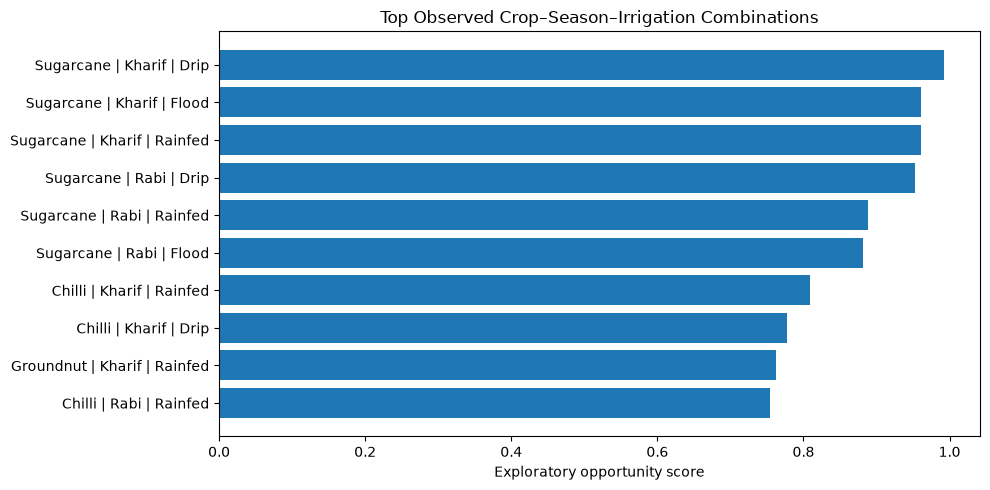

In [22]:
# Visualize the highest-ranked combinations
top = opportunity.sort_values("Opportunity_Score", ascending=False).head(10).copy()
top["Label"] = top["Crop"] + " | " + top["Season"] + " | " + top["Irrigation_Method"]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top["Label"][::-1], top["Opportunity_Score"][::-1])
ax.set_title("Top Observed Crop–Season–Irrigation Combinations")
ax.set_xlabel("Exploratory opportunity score")
plt.tight_layout()
plt.show()


### Why I included this

The score is deliberately simple and transparent. It is **not a machine-learning model** and it is not presented as a recommendation engine. It is a way to combine two project priorities — financial performance and water efficiency — after filtering out very small groups.

That makes the analysis reproducible and easy to explain in a viva.


## 11. Multivariate analysis — what is associated with yield and profit?

In [23]:
# Correlation matrix for selected variables
selected = [
    "Rainfall_mm", "Avg_Temperature_C", "Humidity_pct",
    "Sunlight_Hours_Day", "Soil_pH", "Soil_Moisture_pct",
    "Nitrogen_kg_ha", "Phosphorus_kg_ha", "Potassium_kg_ha",
    "Fertilizer_kg_ha", "Pesticide_Litre_ha", "Seed_Quality_Score",
    "Market_Price_INR_Tonne", "Water_Used_m3",
    "Disease_Pest_Risk_pct", "Farm_Area_Hectares",
    "Yield_Tonnes_Ha", "Profit_INR"
]

corr = data[selected].corr()

print("Variables most correlated with Yield_Tonnes_Ha:")
print(corr["Yield_Tonnes_Ha"].drop("Yield_Tonnes_Ha").sort_values(ascending=False).head(8).round(3))

print("\nVariables most correlated with Profit_INR:")
print(corr["Profit_INR"].drop("Profit_INR").sort_values(ascending=False).head(8).round(3))


Variables most correlated with Yield_Tonnes_Ha:
Profit_INR              0.49
Water_Used_m3           0.39
Nitrogen_kg_ha          0.05
Phosphorus_kg_ha        0.05
Farm_Area_Hectares      0.03
Rainfall_mm             0.03
Disease_Pest_Risk_pct   0.01
Humidity_pct            0.01
Name: Yield_Tonnes_Ha, dtype: float64

Variables most correlated with Profit_INR:
Yield_Tonnes_Ha          0.49
Market_Price_INR_Tonne   0.23
Water_Used_m3            0.19
Farm_Area_Hectares       0.12
Rainfall_mm              0.11
Soil_Moisture_pct        0.09
Nitrogen_kg_ha           0.09
Disease_Pest_Risk_pct    0.07
Name: Profit_INR, dtype: float64


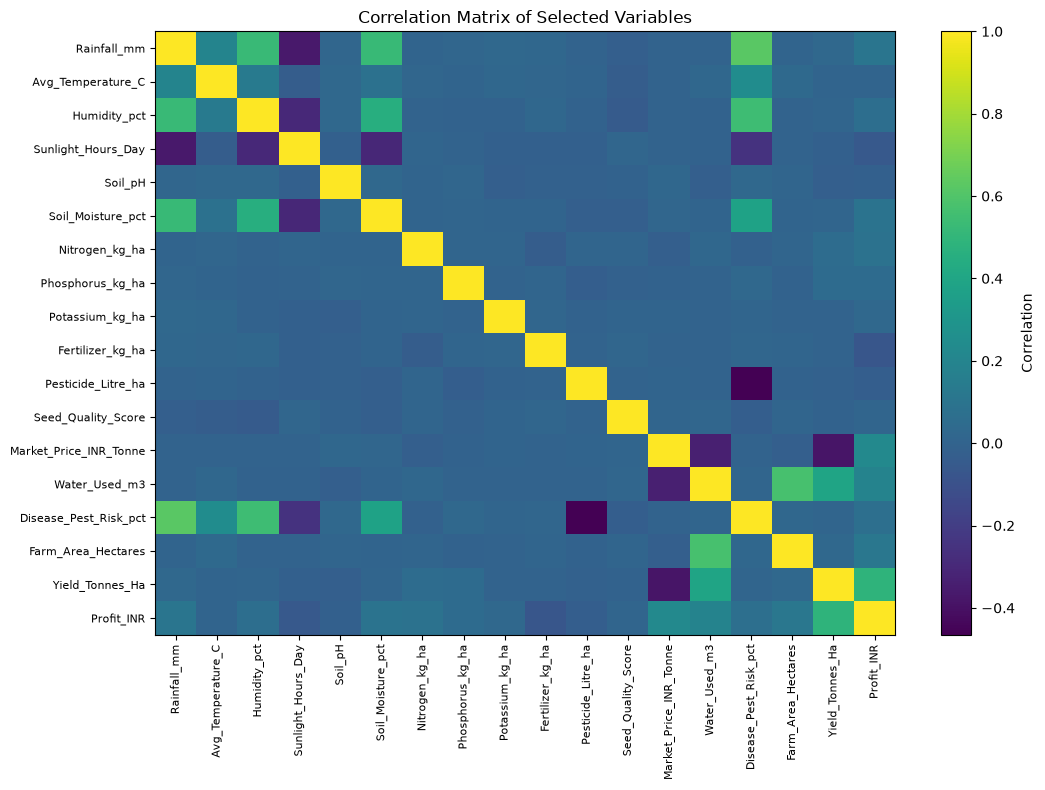

In [24]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(11, 8))
im = ax.imshow(corr.values, aspect="auto")
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index, fontsize=8)
ax.set_title("Correlation Matrix of Selected Variables")
fig.colorbar(im, ax=ax, label="Correlation")
plt.tight_layout()
plt.show()


### Correlation takeaway

Water efficiency has a strong positive association with yield in this dataset, while market price has a negative association with yield. That does **not** mean higher market prices reduce yield; the relationship can arise because different crops have different typical price and yield profiles.

This is an important limitation of simple correlation analysis and is worth mentioning in a presentation.


## 12. Eight evidence-based insights

In [25]:
# Generate a compact evidence table used for the final interpretation
season_summary.round(2)


,Season,Farms,Mean_Yield,Median_Yield,Mean_Profit,Median_Profit,Mean_Water,Mean_Water_Efficiency,Mean_Disease_Risk,Profitable_Farm_Rate
0,Kharif,1779,5.64,1.95,"178,914.65","38,808.00","6,102.20",5.89,54.47,57.79
1,Rabi,1627,5.08,1.66,"87,689.47","-3,187.00","5,846.99",5.19,40.48,48.86
2,Zaid,594,4.67,1.45,"-24,804.82","-62,144.00","6,419.89",4.41,38.22,35.52


### Insights from the analysis

1. **Kharif is the strongest season overall in the supplied data.** It has the highest median yield and median profit among the three seasons.
2. **Zaid carries the greatest profitability risk.** The share of loss-making farms is substantially higher than in Kharif and Rabi.
3. **Crop choice matters as much as season.** Sugarcane and Chilli show much stronger median profitability than several cereal crops.
4. **Drip irrigation is a notable high-efficiency combination.** It records the highest average water efficiency among the four irrigation categories while also having the highest median profit.
5. **Flood irrigation uses considerably more water on average than Rainfed irrigation**, while its water-efficiency figure is lower than Drip and Rainfed.
6. **Mean values can hide the typical farm.** Yield and profit are heavily right-skewed, so median values provide a more realistic view of a typical record.
7. **The dataset contains meaningful financial downside pockets.** Several crop–season combinations have negative median profit and high loss rates, particularly some Zaid combinations.
8. **Profitability is not explained by yield alone.** Market price, production, water efficiency and farm scale are all related to profit, so a useful planning view needs both physical and economic measures.


## 13. Evidence-based recommendations

### Recommendations

**1. Plan by crop + season, not season alone.**  
The analysis suggests that seasonal performance changes substantially with crop choice. Seasonal planning should therefore compare crop–season combinations before using an overall seasonal average.

**2. Give water efficiency a place beside profit.**  
Where irrigation choices are being evaluated, Drip appears promising in the observed records because it combines relatively high water efficiency with positive median profitability.

**3. Investigate high-loss combinations before expanding them.**  
Zaid combinations with high loss rates deserve additional review of input cost, market price, water availability and crop suitability.

**4. Use median performance in routine reporting.**  
Because extreme observations are present, dashboards based only on averages could give an overly optimistic picture.

**5. Treat the findings as screening signals.**  
Before making a real farming decision, the patterns should be validated with more years of data, local agronomic knowledge, input prices and market conditions.


## 14. Limitations

- The analysis is based only on the supplied dataset; it does not establish causality.
- Missing yield values were not artificially imputed for yield-based conclusions.
- Several variables are strongly skewed, so averages can be influenced by extreme observations.
- The dataset does not provide enough information to explain *why* a crop or season performs differently.
- The exploratory opportunity score is a student-designed ranking, not a validated agricultural decision model.
- External factors such as actual weather forecasts, changing input prices, local policies and market shocks are outside this analysis.


## 15. Final conclusion

The main finding is that agricultural performance in this dataset is **not a single-variable problem**. Season, crop choice, irrigation, productivity, water efficiency and economics interact to produce very different outcomes.

Kharif appears to be the strongest overall season, while Zaid has the highest financial downside. At the same time, crop-level analysis shows that some crops behave very differently from the overall seasonal pattern. The irrigation comparison also suggests that water efficiency can be considered alongside profitability rather than treated as a separate issue.

The most practical next step would be to turn these findings into a small seasonal planning dashboard and validate the high-performing and high-risk combinations with additional local data.


---

### Project skills demonstrated

**Python • Pandas • Data Cleaning • Exploratory Data Analysis • Statistical Analysis • Outlier Analysis • Correlation Analysis • GroupBy/Pivot Analysis • Data Visualization • Insight Generation • Evidence-based Recommendations**
